---
title: NPS Homework 5
format:
  poster-typst: 
    size: "36x24"
    poster-authors: ["Liam Jemison"]
    departments: "Mathematics Department"
    institution-logo: "images/logo.png"
    footer-text: "AIM UP REU 2026"
    footer-url: "https://sites.uwm.edu/reu/"
    footer-emails: "ljemison@uwm.edu"
    footer-color: "ebcfb2"
    keywords: ["statistics", "nadaraya-watson"]
    mainfont: "Liberation Serif"
---

# Part A

Consider the Nadaraya-Watson estimator 

$$\hat m (x) = \dfrac{\sum_{j=1}^nK_h(x_j - x) y_j}{ \sum_{i=1}^n K_h(x_i - x)},$$

Where $(x_i, y_i), i = 1,\ldots n,$ is a given sample. We note that the predicted value $\hat{y_k}$ is given by 

\begin{align}
\hat{y_k} &= \dfrac{\sum_{j=1}^nK_h(x_j - x_k) y_j}{\sum_{i=1}^n K_h(x_i - x_k)} \\
    &= H_k Y,
\end{align}

where $H_k$ is row vector with $j$ th entry given by $(H_k)_j = \dfrac{K_h(x_j - x_k)}{ \sum_{i=1}^n K_h(x_i - x_k)}.$ Hence the vector of predictions $\hat y$ is given by 

$$\hat y = H y,$$

where $H_{kj} = (H_k)_j.$ 

# Part B

In light of the calculations above, the generalized cross-validation measure of a Nadaraya Watson estimator with bandwith $h$ is given by 

$$ \text{GCV}(h) = \frac{1}{n}\sum_{i=1}^n \left(\dfrac{y_i - \hat m_h(x)}{1 - \text{Tr}(H)/n}\right)^2, $$

where the trace of the matrix $H$ found above is 

$$\text{Tr}(H) = \sum_{k=1}^n \dfrac{K_h(0)}{ \sum_{i=1}^n K_h(x_i - x_k)}.$$

We thus use the $GCV$ as a heuristic for determing the optimal bandwidth by seeking to minimize $GCV$ over all $(x_i, y_i).$ Below we implement the $GCV$ for a Nadaraya Watson estimator with standard normal kernel. 

In [7]:
from scipy.stats import norm
import numpy as np
def K_h(x, h):
    return (1/h) * norm.pdf(x/h)

def trH(x, h):
    den = np.sum(K_h(x[None, :] - x[:, None], h), axis = 0)
    return np.sum( K_h(0, h) / den)
def GCV(x, y, m, h):
    return np.mean(((y - m) / (1 - trH(x, h)/x.shape[0]))**2)


We consider the "mcycle" dataset in the R Mass package shown below. 

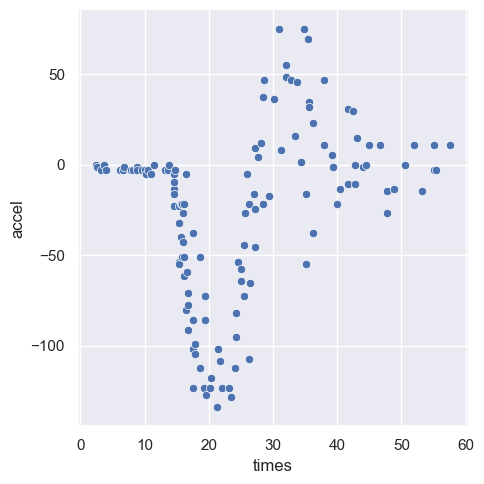

In [9]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
cycle = sm.datasets.get_rdataset("mcycle", "MASS").data
sns.set_theme()
sns.relplot(cycle, x = "times", y = "accel")

We suppose that the accelaration variable $y_i$ is related to the time variable $x_i$ by some nonlinear relationship 

$y_i = m(x_i) + \epsilon,$

where $\epsilon$ is some noise. Below we estimate $m(x)$ using 25 equispaced choices of bandwidth between $h= 0.1$ and $h= 5,$ and compute the generalized cross-validation measure, defined above, for each, as well as the leave-one-out cross-validation metric defined by statsmodels. Based on the CV and GCV, the optimal bandwidth appears to be approximately $h \approx 1.53.$ 

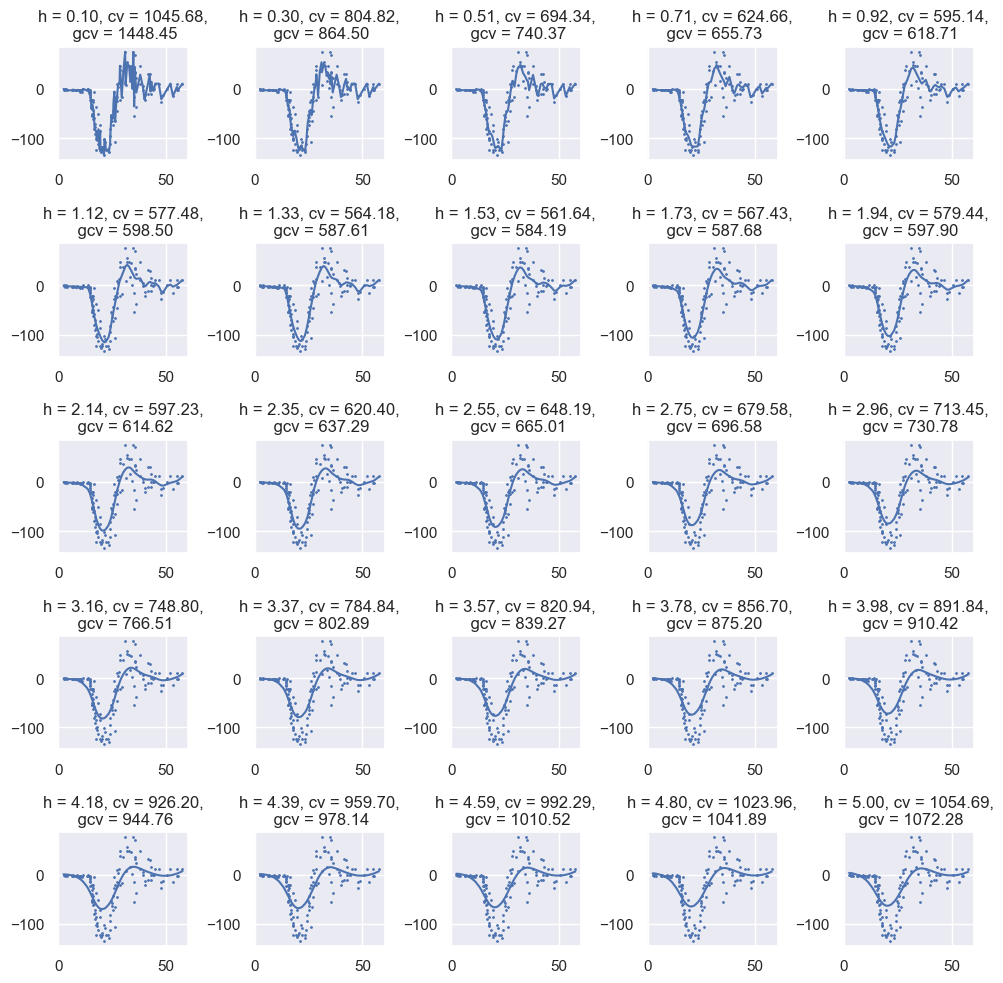

In [10]:

from statsmodels.nonparametric.kernel_regression import KernelReg
import matplotlib.pyplot as plt


fig, plts = plt.subplots(nrows = 5, ncols = 5)
plts = plts.flatten()
for i, h in enumerate(np.linspace(0.1, 5, num = 25)):
    nw = KernelReg(cycle["accel"], cycle["times"], var_type="c", bw=[h])
    y_hat = np.array(nw.fit()[0])
    plts[i].scatter(cycle["times"], cycle["accel"], s = 1)
    plts[i].plot(cycle["times"], y_hat)
    cv = nw.cv_loo(bw = np.array([h]), func=nw.est["ll"] )[0]
    gcv = GCV(cycle["times"].to_numpy(), cycle["accel"].to_numpy(), y_hat, h)
    plts[i].set_title(f"h = {h:.2f}, cv = {cv:.2f},\n gcv = {gcv:.2f}")

fig.set_size_inches(10, 10)
fig.tight_layout()